In [59]:
n = [[0,1],[1,2],[2,3],[4,5],[5,6]]
n2 = [sum(n[j][i] for j in range(len(n))) for i in range(len(n[0]))]
print(n2)



[12, 17]


In [90]:
n=[[1]*3]
n[1:] = [i[0]**2 for i in n[:-1]]
print(n)

[[1, 1, 1]]


In [123]:
import random
print(random.randint(0,1))

0


In [ ]:
import math
import random
import matplotlib.pyplot as plt
lr = 3e-4

def loss(logits, y):
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]
    s = sum(exps)
    return -math.log(exps[y.index(1)] / s)

def grad(logits, y):
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]
    s = sum(exps)
    probs = [e / s for e in exps]
    return [probs[k] - y[k] for k in range(len(logits))]


class Neuron:
    # int
    def __init__(self, inputs,outNeuron = False):
        self.w = [0.01 * random.uniform(-1,1) for _ in range(inputs)]
        self.b = 0
        self.numIn = inputs
        self.out = outNeuron
    # list
    def forwardPass(self, inputs):
        total = sum(i * w for i, w in zip(inputs, self.w)) + self.b
        if self.out:
            return total
        return 1 / (1 + math.exp(-total))
    # list list float
    def backwardPass(self, chain, inp, out):
        if self.out:
            dz = chain
        else:
            dz = chain * (out * (1.0 - out))  # chain
        dz = max(min(dz, 1.0), -1.0)
        wx = [dz * w for w in self.w]     # for backprop
        self.w[:] = [w - lr * dz*i for i, w in zip(inp, self.w)]  # edits weights
        self.b -= lr * dz
        return wx

class Layer:
    #int int
    def __init__(self,inputs,nCount,outLayer = False):
        self.neurons = [Neuron(inputs,outLayer) for _ in range(nCount)]
        self.nCount = nCount
    #list
    def forwardPass(self,inputs):
        return [neuron.forwardPass(inputs) for neuron in self.neurons]
    #list list list
    def backwardPass(self,chain,inputs,outs):
        d = [neuron.backwardPass(chain[i],inputs,outs[i]) for i, neuron in enumerate(self.neurons)]
        chain = [sum(d[j][i] for j in range(len(d))) for i in range(len(d[0]))] #turns [1,2],[2,3] to [3,5] 
        return chain

class NeuralNetwork:
    #list
    def __init__(self,structure):
        self.layers = [Layer(structure[i-1],structure[i]) for i in range(1,len(structure)-1)]
        self.layers.append(Layer(structure[-2],structure[-1],True))
        self.outs = [None for _ in structure]
        self.lossi = []
    #list
    def forwardPass(self,x):
        self.outs[0] = x
        for i, layer in enumerate(self.layers):
            self.outs[i+1] = layer.forwardPass(self.outs[i])
        return self.outs[-1]
    #list
    def backwardPass(self,y):
        chain = grad(self.outs[-1],y)
        for i,layer in reversed(list(enumerate(self.layers))):
            chain = layer.backwardPass(chain,self.outs[i],self.outs[i+1])
        return loss(self.outs[-1],y)
    #list list
    def train(self,X,Y):
        for _ in range(1000):
            for x,y in zip(X,Y):
                self.forwardPass(x)
                self.backwardPass(y)
    
    def batchTrain(self,X,Y):
        for i in range(2000):
            rand = random.randint(0,len(X)-33)
            for j in range(rand,rand+32):
                self.forwardPass(X[j])
                loss = self.backwardPass(Y[j])
                self.lossi.append(loss)
            if (i+1)%100 == 0:
                print(sum(self.lossi[-i] for i in range(1,32))/32)


In [ ]:
nn = NeuralNetwork([1,50,2])
X = [[1],[2],[3],[4],[5],[6]]
Y = [[0,1],[0,1],[0,1],[1,0],[1,0],[1,0]]
nn.stochasticTrain(X,Y)
print(nn.forwardPass([1]))
plt.plot(nn.lossi)

In [256]:
words = open('datasets/names.txt','r').read().lower().splitlines()

# Build vocab with '.' as 0
chars = sorted(list(set(''.join(words))))
vocabSize = len(chars) + 1
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print("vocabSize:", vocabSize)
print("itos (first 10):", {k:itos[k] for k in sorted(itos)[:10]})

blockSize = 2  # context length in characters (here just previous single char)

def oneHot(num, size):
    v = [0]*size
    v[num] = 1
    return v

def buildDataset(words):
    X, Y = [], []
    for w in words:
        context = [0]*blockSize  # start with <.> token index 0
        for ch in w + '.':
            ix = stoi[ch]
            # Input is the one-hot of the current context (size vocabSize*blockSize)
            # Since blockSize=1, this is just one one-hot vector of length vocabSize.
            # If you later increase blockSize, you can concatenate multiple one-hots.
            x_vec = []
            for c in context:
                x_vec.extend(oneHot(c, vocabSize))
            y_vec = oneHot(ix, vocabSize)
            X.append(x_vec)
            Y.append(y_vec)
            # slide the window
            context = context[1:] + [ix]
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = buildDataset(words[:n1])
Xdev, Ydev = buildDataset(words[n1:n2])
Xte, Yte = buildDataset(words[n2:])

inputDim = vocabSize * blockSize
outputDim = vocabSize

print("Sample X shape:", len(Xtr))
print("Sample Y length:", len(Ytr))
print(Xtr[0],Ytr[0])

vocabSize: 27
itos (first 10): {0: '.', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i'}
Sample X shape: 182625
Sample Y length: 182625
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]


2.836039088954744
2.686159031568893
2.6352764916806555
3.024879591118246
2.583729354897021
2.631503961397634
2.688774519384542
2.769938906165409
2.7519550242867785
2.7970552050580375
2.736993872460638
2.7974294232335817
2.516940433927173
2.7713420479760864
2.822726046161588
2.6121642986350495
2.7037994058940917
2.6927855584196934
2.741225730930554
2.6683293056853725


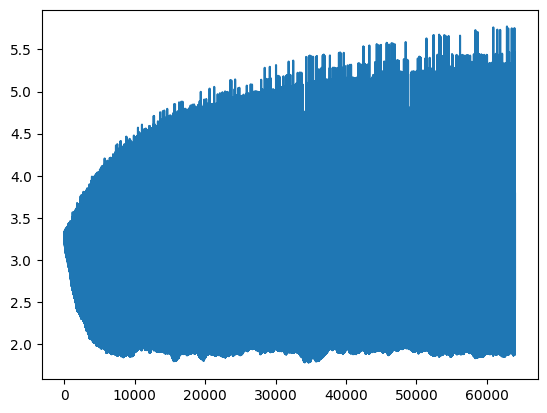

In [257]:
nameNN = NeuralNetwork([inputDim,64,outputDim])
nameNN.batchTrain(Xtr,Ytr)
plt.plot(nameNN.lossi)

In [262]:
name = [".","."]
while(True):
    logits = nameNN.forwardPass(oneHot(stoi[name[-2]],vocabSize)+oneHot(stoi[name[-1]],vocabSize))
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]
    name.append(itos[exps.index(max(exps))])
    if name[-1]==".":
        break
print(name)


KeyboardInterrupt: 